In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv('Pais_Sin_Nulos_Outliers.csv')
df.head()

,Unnamed: 0,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Precio Venta
0,0,city scrape,Nice room with superb city view,Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Nuttee,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,0.0,4.86,4.95,4.82,4.97,4.91,4.66,4.75,0.43,4.95
1,1,previous scrape,"Easy going landlord,easy place",Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Emy,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,0.0,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70
2,2,previous scrape,modern-style apartment in Bangkok,A modern-style apartment situated in a cool ne...,Ramkumheang neigbourhood - hip place with food...,Familyroom,12/05/2010,"Bangkok, Thailand",Welcome to Familyroom Apartment.\r\n\r\nA Chic...,within an hour,...,0.0,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70
3,3,city scrape,Spacious one bedroom at The Kris Condo Bldg. 3,Cozy and clean apartment at MRT Sutthisarn sta...,"There is McDonald's, Au bon Pain and Max Value...",Sirilak,27/06/2010,"Bangkok, Thailand",from Bangkok but I'm in and out of the city a ...,within an hour,...,0.0,4.83,5.00,4.67,4.50,4.83,4.83,5.00,0.06,5.00
4,4,city scrape,Condo with Chaopraya River View,at a size of 25sqm for your vacation in BKK.<b...,"There is McDonald's, Au bon Pain and Max Value...",Athitaya,03/09/2010,"Bangkok, Thailand","Full-time legal consultant from Bangkok, Thail...",within an hour,...,0.0,5.00,5.00,5.00,5.00,5.00,5.00,5.00,0.01,5.00


In [29]:
df = df[df['room_type'] == 'Entire home/apt']

In [107]:
df['price'].info()

<class 'pandas.core.series.Series'>
Index: 15885 entries, 0 to 25078
Series name: price
Non-Null Count  Dtype 
--------------  ----- 
15885 non-null  object
dtypes: object(1)
memory usage: 248.2+ KB


In [108]:
df['host_identity_verified'].info()

<class 'pandas.core.series.Series'>
Index: 15885 entries, 0 to 25078
Series name: host_identity_verified
Non-Null Count  Dtype 
--------------  ----- 
15885 non-null  object
dtypes: object(1)
memory usage: 248.2+ KB


In [30]:
df['price'] = df['price'].str.replace('$', '', regex=False)

In [31]:
df['price'] = df['price'].str.replace('.00', '', regex=False)

In [32]:
df['price'] = df['price'].str.replace(',000', '', regex=False)

In [33]:
df['price'] = df['price'].str.replace(',', '.', regex=False)

In [34]:
df['price'] = df['price'].astype(float)

In [35]:
df['host_identity_verified'] = df['host_identity_verified'].replace({'t': 1, 'f': 0}).astype(int)

C:\Users\issei\AppData\Local\Temp\ipykernel_25588\1014031884.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['host_identity_verified'] = df['host_identity_verified'].replace({'t': 1, 'f': 0}).astype(int)


C:\Users\issei\AppData\Local\Temp\ipykernel_25588\2518764000.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


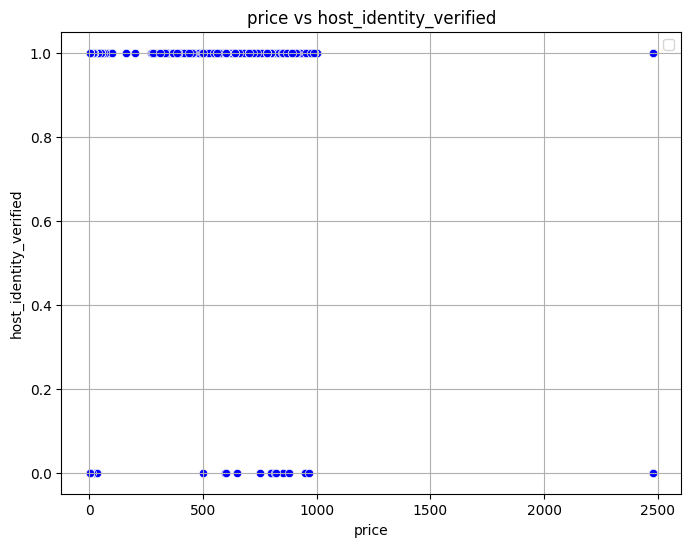

In [36]:
from turtle import color

plt.figure(figsize=(8, 6))
sns.scatterplot(y='host_identity_verified', x='price',  color = 'blue', data=df)
plt.title('price vs host_identity_verified')
plt.xlabel('price')
plt.ylabel('host_identity_verified')
plt.legend()
plt.grid(True)
plt.show()

In [37]:
indep= df[['host_identity_verified']]
dep = df[['price']]

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [39]:
model.fit(indep, dep)

LinearRegression()

In [40]:
type(model)

sklearn.linear_model._base.LinearRegression

In [41]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['host_identity_verified'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([[-1812.85872377]]),
 'rank_': 1,
 'singular_': array([27.06797887]),
 'intercept_': array([2172.3321974])}

In [42]:
m = model.coef_
b = model.intercept_
print('Pendiente:', m)
print('Intercepto:', b)

# Entonce, el modelo lineal sería:
print(f'y = {m[0]}x + {b}')

Pendiente: [[-1812.85872377]]
Intercepto: [2172.3321974]
y = [-1812.85872377]x + [2172.3321974]


In [43]:
r2 = model.score(indep, dep)
r2

0.23392294019464266

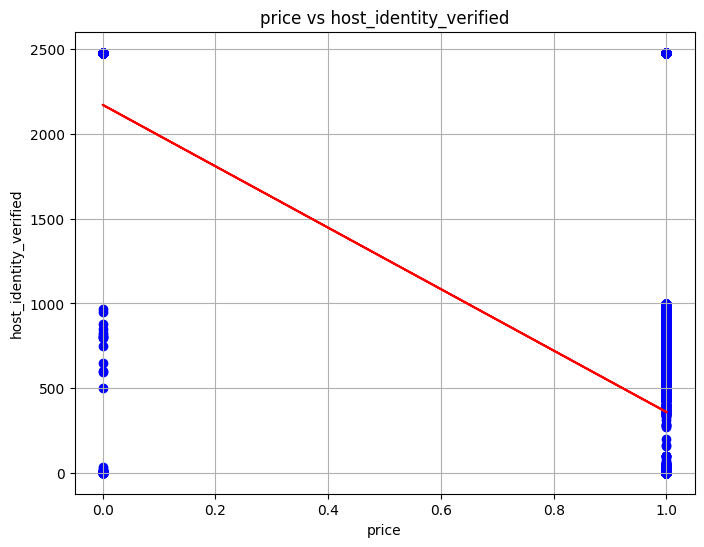

In [44]:
plt.figure(figsize=(8, 6))
plt.scatter(indep, dep, color='blue')
plt.plot(indep, model.predict(indep), color='red')
plt.title('price vs host_identity_verified')
plt.xlabel('price')
plt.ylabel('host_identity_verified')
plt.grid(True)
plt.show()

In [45]:
yPred = model.predict(df[['host_identity_verified']])
yPred

array([[359.47347364],
       [359.47347364],
       [359.47347364],
       ...,
       [359.47347364],
       [359.47347364],
       [359.47347364]])

In [46]:
df['Predicciones'] = yPred
df.head()

,Unnamed: 0,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Precio Venta,Predicciones
0,0,city scrape,Nice room with superb city view,Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Nuttee,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,4.86,4.95,4.82,4.97,4.91,4.66,4.75,0.43,4.95,359.473474
8,8,city scrape,"Cozy and spacious 1BR with great view, LT rent","The cozy one bed room apartment, conveniently ...","Charoen krung street, River pier, Iconsiam, Su...",Jean,27/10/2010,"Nonthaburi, Thailand","I love traveling and experience local culture,...",within a few hours,...,4.88,4.71,4.82,4.81,4.69,4.50,4.80,0.11,4.71,359.473474
9,9,city scrape,Central Bangkok 3 Bedroom Apartment,We are Airbnb Super Hosts. Book our apartment ...,Sukhumvit Rd is the shopping and restaurant di...,Henry,30/04/2011,"Bangkok, Thailand",Hello!\r\n\r\nOur collection of privately owne...,a few days or more,...,4.77,4.84,4.85,4.86,4.89,4.86,4.76,0.93,4.84,359.473474
13,13,city scrape,Studio near Chula University/Silom walk to MRT,A centrally located studio apartment with wifi...,It's central yet very local - you'll find easi...,Gael,01/12/2009,"Ko Samui, Thailand","I'm french, living in Samui and Bangkok.\r\n\r...",within a few hours,...,4.80,4.56,4.80,4.90,4.90,4.35,4.80,0.47,4.56,359.473474
14,14,previous scrape,Nice and Cozy Room @ Sathorn Area,A centrally located studio apartment with wifi...,It's central yet very local - you'll find easi...,Wirat,01/07/2011,"Bangkok, Thailand",Nice and Cozy Room @ Sathorn Area. \r\nOne Bed...,within a few hours,...,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70,2172.332197


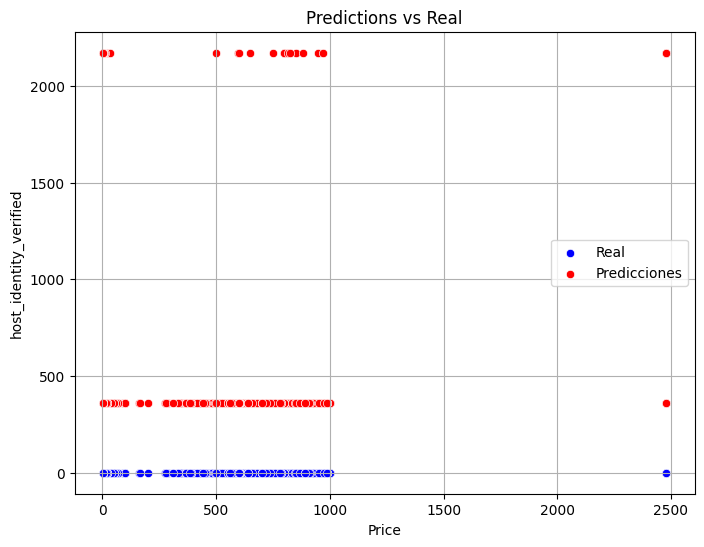

In [47]:
plt.figure(figsize=(8, 6 ))
sns.scatterplot(x='price', y='host_identity_verified', color='blue', data=df, label='Real')
sns.scatterplot(x='price', y='Predicciones', color='red', data=df, label='Predicciones')
#sns.lineplot(x='alcohol', y='Predicciones', color='red', data=df, label='Predicciones')
plt.title('Predictions vs Real')
plt.xlabel('Price')
plt.ylabel('host_identity_verified')
plt.legend()
plt.grid(True)
plt.show()

In [48]:
coefDe = model.score(indep, dep)
coefDe

0.23392294019464266

In [49]:
coefCo = np.sqrt(coefDe)
coefCo

0.48365580756840154

In [129]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('Half-bath', '.5', regex=False)

In [130]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('bath', '', regex=False)

In [131]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('baths', '', regex=False)

In [132]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('s', '', regex=False)

In [133]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('Half-', '.5', regex=False)

In [134]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('shared bath', '', regex=False)

In [135]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('shared','', regex=False)

In [136]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('private bath', '', regex=False)

In [137]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('private', '', regex=False)

In [138]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('Shared half-', '.5', regex=False)

In [139]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('shared baths', '', regex=False)

In [140]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('Private half-', '.5', regex=False)

In [141]:
df['bathrooms_text'] = df['bathrooms_text'].astype(float)

In [142]:
df['host_is_superhost'] = df['host_is_superhost'].replace({'f': 0, 't': 1}).astype(float)

<ipython-input-142-1126a6e5cd06>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['host_is_superhost'] = df['host_is_superhost'].replace({'f': 0, 't': 1}).astype(float)


In [143]:
df['instant_bookable'] = df['instant_bookable'].replace({'f': 0, 't': 1}).astype(float)

<ipython-input-143-33deb354eca7>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['instant_bookable'] = df['instant_bookable'].replace({'f': 0, 't': 1}).astype(float)


In [144]:
df['host_acceptance_rate'] = df['host_acceptance_rate'].str.replace('%', '', regex=False)

In [145]:
df['host_acceptance_rate'] = df['host_acceptance_rate'].astype(float)

In [146]:
df['host_response_rate'] = df['host_response_rate'].str.replace('%', '', regex=False)

In [147]:
df['host_response_rate'] = df['host_response_rate'].astype(float)

In [148]:
df['has_availability'] = df['has_availability'].replace({'f': 0, 't': 1}).astype(float)

<ipython-input-148-a5f192c334b4>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['has_availability'] = df['has_availability'].replace({'f': 0, 't': 1}).astype(float)


In [149]:
#df = df[['host_response_rate','host_acceptance_rate','host_identity_verified','host_is_superhost', 'price','accommodates','bathrooms_text','review_scores_cleanliness','Precio Venta','reviews_per_month','review_scores_value','review_scores_location','review_scores_communication','review_scores_checkin','review_scores_cleanliness','review_scores_accuracy','review_scores_rating','number_of_reviews_ltm','number_of_reviews','availability_365','availability_90','availability_60','availability_30','maximum_nights','minimum_nights','beds','bedrooms','host_total_listings_count','host_listings_count','instant_bookable','has_availability']]
#df

In [150]:
df = df[['host_acceptance_rate','host_is_superhost','price','accommodates','bathrooms_text','review_scores_cleanliness','host_identity_verified','instant_bookable','host_total_listings_count','bedrooms','review_scores_value','reviews_per_month']]

In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15885 entries, 0 to 25078
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   host_acceptance_rate       15885 non-null  float64
 1   host_is_superhost          15885 non-null  float64
 2   price                      15885 non-null  float64
 3   accommodates               15885 non-null  float64
 4   bathrooms_text             15885 non-null  float64
 5   review_scores_cleanliness  15885 non-null  float64
 6   host_identity_verified     15885 non-null  int64  
 7   instant_bookable           15885 non-null  float64
 8   host_total_listings_count  15885 non-null  float64
 9   bedrooms                   15885 non-null  float64
 10  review_scores_value        15885 non-null  float64
 11  reviews_per_month          15885 non-null  float64
dtypes: float64(11), int64(1)
memory usage: 1.6 MB


In [152]:
correlacion = df.corr()
correlacion

,host_acceptance_rate,host_is_superhost,price,accommodates,bathrooms_text,review_scores_cleanliness,host_identity_verified,instant_bookable,host_total_listings_count,bedrooms,review_scores_value,reviews_per_month
host_acceptance_rate,1.000000,0.204434,0.019315,0.049610,0.040749,0.100425,-0.004928,0.382086,-0.008974,-0.003485,0.087615,0.005643
host_is_superhost,0.204434,1.000000,-0.126904,0.015818,0.005570,0.228108,0.150701,-0.007772,-0.041745,-0.054156,0.203646,0.015506
price,0.019315,-0.126904,1.000000,-0.110823,-0.081885,-0.044248,-0.483656,-0.086470,-0.152816,0.202318,-0.037275,-0.087042
accommodates,0.049610,0.015818,-0.110823,1.000000,0.315790,-0.021846,0.001804,0.035783,-0.065243,-0.040468,-0.012477,0.059538
bathrooms_text,0.040749,0.005570,-0.081885,0.315790,1.000000,0.001588,-0.003445,0.020340,-0.089223,-0.031989,0.007810,0.024879
review_scores_cleanliness,0.100425,0.228108,-0.044248,-0.021846,0.001588,1.000000,0.062295,0.000948,-0.075326,-0.007970,0.597797,-0.251664
host_identity_verified,-0.004928,0.150701,-0.483656,0.001804,-0.003445,0.062295,1.000000,0.172384,0.180578,-0.223843,0.065536,-0.012113
instant_bookable,0.382086,-0.007772,-0.086470,0.035783,0.020340,0.000948,0.172384,1.000000,0.193278,-0.061250,0.000505,0.041385
host_total_listings_count,-0.008974,-0.041745,-0.152816,-0.065243,-0.089223,-0.075326,0.180578,0.193278,1.000000,-0.070083,-0.076937,0.055889
bedrooms,-0.003485,-0.054156,0.202318,-0.040468,-0.031989,-0.007970,-0.223843,-0.061250,-0.070083,1.000000,-0.008882,-0.020249


In [153]:
corr = abs(correlacion)
corr

,host_acceptance_rate,host_is_superhost,price,accommodates,bathrooms_text,review_scores_cleanliness,host_identity_verified,instant_bookable,host_total_listings_count,bedrooms,review_scores_value,reviews_per_month
host_acceptance_rate,1.000000,0.204434,0.019315,0.049610,0.040749,0.100425,0.004928,0.382086,0.008974,0.003485,0.087615,0.005643
host_is_superhost,0.204434,1.000000,0.126904,0.015818,0.005570,0.228108,0.150701,0.007772,0.041745,0.054156,0.203646,0.015506
price,0.019315,0.126904,1.000000,0.110823,0.081885,0.044248,0.483656,0.086470,0.152816,0.202318,0.037275,0.087042
accommodates,0.049610,0.015818,0.110823,1.000000,0.315790,0.021846,0.001804,0.035783,0.065243,0.040468,0.012477,0.059538
bathrooms_text,0.040749,0.005570,0.081885,0.315790,1.000000,0.001588,0.003445,0.020340,0.089223,0.031989,0.007810,0.024879
review_scores_cleanliness,0.100425,0.228108,0.044248,0.021846,0.001588,1.000000,0.062295,0.000948,0.075326,0.007970,0.597797,0.251664
host_identity_verified,0.004928,0.150701,0.483656,0.001804,0.003445,0.062295,1.000000,0.172384,0.180578,0.223843,0.065536,0.012113
instant_bookable,0.382086,0.007772,0.086470,0.035783,0.020340,0.000948,0.172384,1.000000,0.193278,0.061250,0.000505,0.041385
host_total_listings_count,0.008974,0.041745,0.152816,0.065243,0.089223,0.075326,0.180578,0.193278,1.000000,0.070083,0.076937,0.055889
bedrooms,0.003485,0.054156,0.202318,0.040468,0.031989,0.007970,0.223843,0.061250,0.070083,1.000000,0.008882,0.020249


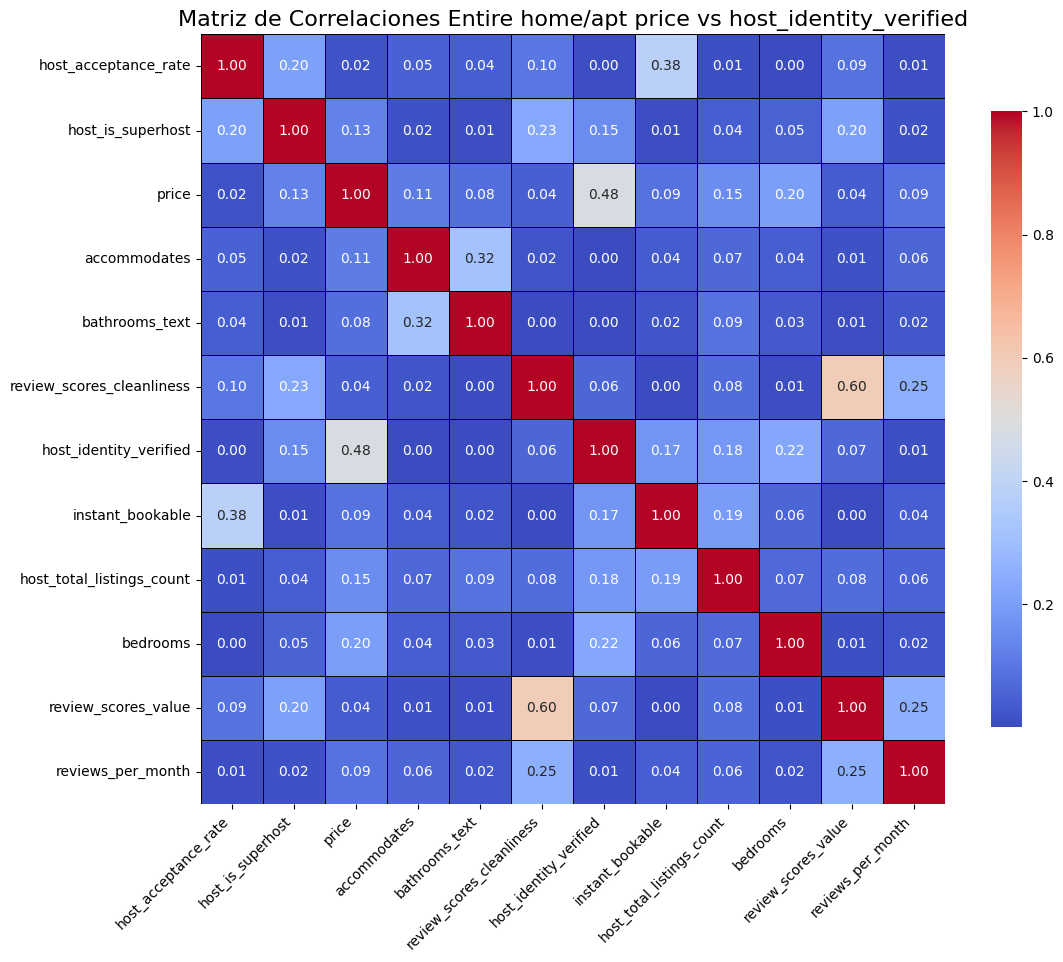

In [154]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, linecolor='black', cbar_kws={'shrink': 0.8}, annot_kws={"size": 10})
plt.title('Matriz de Correlaciones Entire home/apt price vs host_identity_verified', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.show()